<a href="https://colab.research.google.com/github/donw385/Big-Data-Bowl/blob/master/NFL_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [0]:
#imports 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import altair as alt
import itertools
import re
from vega_datasets import data
pd.options.display.max_columns = 500



In [0]:
#read data

games = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/games.csv')
players = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/players.csv')
plays = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/plays.csv')

In [0]:
games.shape, players.shape, plays.shape

((91, 21), (1713, 10), (14193, 27))

In [0]:
games.columns

Index(['season', 'week', 'gameDate', 'gameId', 'gameTimeEastern', 'HomeScore',
       'VisitorScore', 'homeTeamAbbr', 'visitorTeamAbbr', 'homeDisplayName',
       'visitorDisplayName', 'Stadium', 'Location', 'StadiumType', 'Turf',
       'GameLength', 'GameWeather', 'Temperature', 'Humidity', 'WindSpeed',
       'WindDirection'],
      dtype='object')

In [0]:
players.head()

,nflId,FirstName,LastName,PositionAbbr,EntryYear,DraftRound,DraftNumber,Height,Weight,College
0,79860,John,Stafford,QB,2009,1.0,1.0,"6'03""",220,Georgia
1,71465,Andre,Smith,T,2009,1.0,6.0,"6'04""",325,Alabama
2,80427,Darrius,Heyward-Bey,WR,2009,1.0,7.0,"6'02""",210,Maryland
3,71269,Michael,Crabtree,WR,2009,1.0,10.0,"6'01""",214,Texas Tech
4,71423,Brian,Orakpo,OLB,2009,1.0,13.0,"6'04""",257,Texas


In [0]:
def decimalize_feet(s):
    m = re.match(r'^(\d+)\'(\d+)\"$', s)
    if m:
        return float(m.group(1)) + float(m.group(2)) / 12.
    else:
        return None
  
players['Height'] = players['Height'].apply(lambda x:decimalize_feet(x))


In [61]:
players.head()

,nflId,FirstName,LastName,PositionAbbr,EntryYear,DraftRound,DraftNumber,Height,Weight,College
0,79860,John,Stafford,QB,2009,1.0,1.0,6.250000,220,Georgia
1,71465,Andre,Smith,T,2009,1.0,6.0,6.333333,325,Alabama
2,80427,Darrius,Heyward-Bey,WR,2009,1.0,7.0,6.166667,210,Maryland
3,71269,Michael,Crabtree,WR,2009,1.0,10.0,6.083333,214,Texas Tech
4,71423,Brian,Orakpo,OLB,2009,1.0,13.0,6.333333,257,Texas


In [0]:
players.columns

Index(['nflId', 'FirstName', 'LastName', 'PositionAbbr', 'EntryYear',
       'DraftRound', 'DraftNumber', 'Height', 'Weight', 'College'],
      dtype='object')

In [69]:
position_summary = players.groupby('PositionAbbr').describe()
position_summary.head(25)



DraftNumber                                                       \
                   count        mean        std    min     25%    50%     75%   
PositionAbbr                                                                    
C                   43.0  114.651163  75.048202   15.0   55.50   93.0  189.00   
CB                 131.0   99.992366  72.980766    5.0   30.50   89.0  157.50   
DB                   1.0   24.000000        NaN   24.0   24.00   24.0   24.00   
DE                 103.0   82.737864  66.093214    1.0   31.50   69.0  119.00   
DT                  81.0   98.160494  70.384028    2.0   44.00   88.0  151.00   
FB                  10.0  174.500000  37.936350  108.0  144.00  186.5  204.00   
FS                  56.0  105.303571  74.967610   14.0   38.75   84.0  174.75   
G                   74.0   93.229730  59.259251    2.0   45.75   81.5  133.75   
ILB                 41.0  104.585366  74.413028    7.0   40.00  113.0  154.00   
K                   12.0  183.750000  37.863691  118.0  164.75  176.0  200.75   
LB                   1.0  232.000000        NaN  232.0  232.00  232.0  232.00   
LS                   3.0  175.000000  63.976558  116.0  141.00  166.0  204.50   
MLB                 28.0  102.142857  72.984886    9.0   38.00   87.5  162.00   
NT                  18.0   95.666667  54.785142   27.0   43.75   89.5  123.00   
OLB                 97.0   95.989691  69.079286    1.0   36.00   83.0  153.00   
P                   16.0  174.000000  45.410718   70.0  151.75  183.5  204.00   
QB                  47.0   75.085106  79.718480    1.0    3.00   52.0  135.00   
RB                  85.0  110.835294  64.440975    4.0   57.00  106.0  154.00   
SS                  46.0  100.130435  61.735136    5.0   51.75   99.0  143.50   
T                   80.0   89.025000  78.965138    1.0   20.75   63.0  153.50   
TE                  76.0  106.671053  63.478582    6.0   50.75   99.0  159.25   
WR                 136.0   90.985294  67.120564    3.0   33.75   80.5  141.25   

                    DraftRound                                                \
                max      count      mean       std  min  25%  50%   75%  max   
PositionAbbr                                                                   
C             251.0       43.0  3.744186  2.036489  1.0  2.0  3.0  6.00  7.0   
CB            254.0      131.0  3.381679  2.024686  1.0  1.0  3.0  5.00  7.0   
DB             24.0        1.0  1.000000       NaN  1.0  1.0  1.0  1.00  1.0   
DE            239.0      103.0  2.980583  1.782159  1.0  1.5  3.0  4.00  7.0   
DT            249.0       81.0  3.370370  1.900292  1.0  2.0  3.0  5.00  7.0   
FB            215.0       10.0  5.500000  0.971825  4.0  5.0  6.0  6.00  7.0   
FS            245.0       56.0  3.607143  2.086132  1.0  2.0  3.0  6.00  7.0   
G             243.0       74.0  3.243243  1.611694  1.0  2.0  3.0  4.00  7.0   
ILB           250.0       41.0  3.512195  2.013976  1.0  2.0  4.0  5.00  7.0   
K             256.0       12.0  5.833333  0.937437  4.0  5.0  6.0  6.25  7.0   
LB            232.0        1.0  7.000000       NaN  7.0  7.0  7.0  7.00  7.0   
LS            243.0        3.0  5.333333  1.527525  4.0  4.5  5.0  6.00  7.0   
MLB           251.0       28.0  3.464286  1.914509  1.0  2.0  3.0  5.00  7.0   
NT            220.0       18.0  3.222222  1.592466  1.0  2.0  3.0  4.00  7.0   
OLB           233.0       97.0  3.319588  1.934050  1.0  2.0  3.0  5.00  7.0   
P             235.0       16.0  5.500000  1.211060  3.0  5.0  6.0  6.00  7.0   
QB            250.0       47.0  2.787234  2.042336  1.0  1.0  2.0  4.00  7.0   
RB            252.0       85.0  3.717647  1.756700  1.0  2.0  4.0  5.00  7.0   
SS            244.0       46.0  3.456522  1.656053  1.0  2.0  3.5  5.00  7.0   
T             255.0       80.0  3.100000  2.138259  1.0  1.0  2.0  5.00  7.0   
TE            246.0       76.0  3.618421  1.781139  1.0  2.0  3.0  5.00  7.0   
WR            245.0      136.0  3.176471  1.861431  1.0  2.0  3.0  

In [0]:
height_and_weight = position_summary.loc[:, list(itertools.product(['Height','Weight'], ['50%']))]


In [75]:
height_and_weight

,Height,Weight
,50%,50%
PositionAbbr,,
C,6.333333,305.0
CB,6.000000,195.0
DB,6.000000,195.0
DE,6.333333,272.5
DT,6.250000,305.0
FB,6.083333,240.0
FS,6.000000,205.0
G,6.333333,314.0


In [38]:
position_summary.head(25)

PositionAbbr DraftNumber                                               \
                      count        mean        std    min     25%    50%   
0             C        43.0  114.651163  75.048202   15.0   55.50   93.0   
1            CB       131.0   99.992366  72.980766    5.0   30.50   89.0   
2            DB         1.0   24.000000        NaN   24.0   24.00   24.0   
3            DE       103.0   82.737864  66.093214    1.0   31.50   69.0   
4            DT        81.0   98.160494  70.384028    2.0   44.00   88.0   
5            FB        10.0  174.500000  37.936350  108.0  144.00  186.5   
6            FS        56.0  105.303571  74.967610   14.0   38.75   84.0   
7             G        74.0   93.229730  59.259251    2.0   45.75   81.5   
8           ILB        41.0  104.585366  74.413028    7.0   40.00  113.0   
9             K        12.0  183.750000  37.863691  118.0  164.75  176.0   
10           LB         1.0  232.000000        NaN  232.0  232.00  232.0   
11           LS         3.0  175.000000  63.976558  116.0  141.00  166.0   
12          MLB        28.0  102.142857  72.984886    9.0   38.00   87.5   
13           NT        18.0   95.666667  54.785142   27.0   43.75   89.5   
14          OLB        97.0   95.989691  69.079286    1.0   36.00   83.0   
15            P        16.0  174.000000  45.410718   70.0  151.75  183.5   
16           QB        47.0   75.085106  79.718480    1.0    3.00   52.0   
17           RB        85.0  110.835294  64.440975    4.0   57.00  106.0   
18           SS        46.0  100.130435  61.735136    5.0   51.75   99.0   
19            T        80.0   89.025000  78.965138    1.0   20.75   63.0   
20           TE        76.0  106.671053  63.478582    6.0   50.75   99.0   
21           WR       136.0   90.985294  67.120564    3.0   33.75   80.5   

                  DraftRound                                                \
       75%    max      count      mean       std  min  25%  50%   75%  max   
0   189.00  251.0       43.0  3.744186  2.036489  1.0  2.0  3.0  6.00  7.0   
1   157.50  254.0      131.0  3.381679  2.024686  1.0  1.0  3.0  5.00  7.0   
2    24.00   24.0        1.0  1.000000       NaN  1.0  1.0  1.0  1.00  1.0   
3   119.00  239.0      103.0  2.980583  1.782159  1.0  1.5  3.0  4.00  7.0   
4   151.00  249.0       81.0  3.370370  1.900292  1.0  2.0  3.0  5.00  7.0   
5   204.00  215.0       10.0  5.500000  0.971825  4.0  5.0  6.0  6.00  7.0   
6   174.75  245.0       56.0  3.607143  2.086132  1.0  2.0  3.0  6.00  7.0   
7   133.75  243.0       74.0  3.243243  1.611694  1.0  2.0  3.0  4.00  7.0   
8   154.00  250.0       41.0  3.512195  2.013976  1.0  2.0  4.0  5.00  7.0   
9   200.75  256.0       12.0  5.833333  0.937437  4.0  5.0  6.0  6.25  7.0   
10  232.00  232.0        1.0  7.000000       NaN  7.0  7.0  7.0  7.00  7.0   
11  204.50  243.0        3.0  5.333333  1.527525  4.0  4.5  5.0  6.00  7.0   
12  162.00  251.0       28.0  3.464286  1.914509  1.0  2.0  3.0  5.00  7.0   
13  123.00  220.0       18.0  3.222222  1.592466  1.0  2.0  3.0  4.00  7.0   
14  153.00  233.0       97.0  3.319588  1.934050  1.0  2.0  3.0  5.00  7.0   
15  204.00  235.0       16.0  5.500000  1.211060  3.0  5.0  6.0  6.00  7.0   
16  135.00  250.0       47.0  2.787234  2.042336  1.0  1.0  2.0  4.00  7.0   
17  154.00  252.0       85.0  3.717647  1.756700  1.0  2.0  4.0  5.00  7.0   
18  143.50  244.0       46.0  3.456522  1.656053  1.0  2.0  3.5  5.00  7.0   
19  153.50  255.0       80.0  3.100000  2.138259  1.0  1.0  2.0  5.00  7.0   
20  159.25  246.0       76.0  3.618421  1.781139  1.0  2.0  3.0  5.00  7.0   
21  141.25  245.0      136.0  3.176471  1.861431  1.0  2.0  3.0  4.25  7.0   

   EntryYear                                                                   \
       count         mean       std     min      25%     50%      75%     max   
0       55.0  2013.509091  2.500909  2007.0  2012.00  2014.0  2015.50  2017.0   
1      180.0  2013.872222  2.857961  2003.0  2012.00  2014.0  

In [0]:
position_table.corr()

DraftNumber  DraftRound  EntryYear    Weight  \
PositionAbbr                                                             
C            DraftNumber     1.000000    0.988643   0.086650 -0.198943   
             DraftRound      0.988643    1.000000   0.086616 -0.200398   
             EntryYear       0.086650    0.086616   1.000000 -0.024386   
             Weight         -0.198943   -0.200398  -0.024386  1.000000   
             nflId           0.216379    0.232066   0.571033 -0.049055   
CB           DraftNumber     1.000000    0.987827   0.097209 -0.058975   
             DraftRound      0.987827    1.000000   0.071561 -0.048948   
             EntryYear       0.097209    0.071561   1.000000 -0.046698   
             Weight         -0.058975   -0.048948  -0.046698  1.000000   
             nflId          -0.058096   -0.078917   0.507584 -0.117335   
DB           DraftNumber          NaN         NaN        NaN       NaN   
             DraftRound           NaN         NaN        NaN       NaN   
             EntryYear            NaN         NaN        NaN       NaN   
             Weight               NaN         NaN        NaN  1.000000   
             nflId                NaN         NaN        NaN  0.075721   
DE           DraftNumber     1.000000    0.986020   0.174373  0.136636   
             DraftRound      0.986020    1.000000   0.159374  0.113690   
             EntryYear       0.174373    0.159374   1.000000 -0.078103   
             Weight          0.136636    0.113690  -0.078103  1.000000   
             nflId           0.199362    0.204974   0.475994 -0.019766   
DT           DraftNumber     1.000000    0.986838   0.175647 -0.131091   
             DraftRound      0.986838    1.000000   0.150036 -0.147413   
             EntryYear       0.175647    0.150036   1.000000 -0.115176   
             Weight         -0.131091   -0.147413  -0.115176  1.000000   
             nflId          -0.115955   -0.119020   0.479258 -0.049127   
FB           DraftNumber     1.000000    0.926742   0.307733 -0.083367   
             DraftRound      0.926742    1.000000   0.208313 -0.116823   
             EntryYear       0.307733    0.208313   1.000000 -0.142014   
             Weight         -0.083367   -0.116823  -0.142014  1.000000   
             nflId           0.330435    0.177525   0.904426 -0.143813   
...                               ...         ...        ...       ...   
QB           DraftNumber     1.000000    0.992590   0.011159 -0.156069   
             DraftRound      0.992590    1.000000   0.004270 -0.200955   
             EntryYear       0.011159    0.004270   1.000000  0.018107   
             Weight         -0.156069   -0.200955   0.018107  1.000000   
             nflId           0.183298    0.195435   0.183136  0.027977   
RB           DraftNumber     1.000000    0.984642   0.283074 -0.215357   
             DraftRound      0.984642    1.000000   0.250468 -0.234296   
             EntryYear       0.283074    0.250468   1.000000  0.120618   
             Weight         -0.215357   -0.234296   0.120618  1.000000   
             nflId           0.275613    0.278097   0.522237 -0.018618   
SS           DraftNumber     1.000000    0.984265   0.022302 -0.228467   
             DraftRound      0.984265    1.000000  -0.037249 -0.221249   
             EntryYear       0.022302   -0.037249   1.000000 -0.123798   
             Weight         -0.228467   -0.221249  -0.123798  1.000000   
             nflId           0.159114    0.097983   0.564526 -0.259491   
T            DraftNumber     1.000000    0.990090   0.121097  0.106286   
             DraftRound      0.990090    1.000000   0.091849  0.112592   
             EntryYear       0.121097    0.091849   1.000000 -0.237878   
             Weight          0.106286    0.112592  -0.237878  1.000000   
             nflId           0.109229    0.095132   0.366452 -0.062020   
TE           DraftNumber     1.000000    0.983331   0.163572 -0.060558   
             DraftRound      0

In [0]:
plays.columns

Index(['gameId', 'playId', 'quarter', 'GameClock', 'down', 'yardsToGo',
       'possessionTeam', 'yardlineSide', 'yardlineNumber', 'offenseFormation',
       'personnel.offense', 'defendersInTheBox', 'numberOfPassRushers',
       'personnel.defense', 'HomeScoreBeforePlay', 'VisitorScoreBeforePlay',
       'HomeScoreAfterPlay', 'VisitorScoreAfterPlay', 'isPenalty', 'isSTPlay',
       'SpecialTeamsPlayType', 'KickReturnYardage', 'PassLength', 'PassResult',
       'YardsAfterCatch', 'PlayResult', 'playDescription'],
      dtype='object')

In [0]:
plays.corr()

,gameId,playId,quarter,down,yardsToGo,yardlineNumber,defendersInTheBox,numberOfPassRushers,HomeScoreBeforePlay,VisitorScoreBeforePlay,HomeScoreAfterPlay,VisitorScoreAfterPlay,isPenalty,isSTPlay,KickReturnYardage,PassLength,YardsAfterCatch,PlayResult
gameId,1.000000,0.018988,0.013187,-0.000862,0.000666,0.012747,0.016871,0.008601,-0.007062,0.054101,-0.007333,0.054427,-0.010558,-0.002263,0.051044,-0.001278,0.001582,-0.005120
playId,0.018988,1.000000,0.955868,0.014076,0.014536,-0.013426,-0.056178,-0.025057,0.671160,0.720285,0.668935,0.719514,0.008493,-0.017799,0.007440,0.016704,-0.019644,-0.034929
quarter,0.013187,0.955868,1.000000,0.009019,0.009263,-0.008180,-0.039017,-0.011141,0.629000,0.687918,0.626699,0.686909,0.005411,-0.015540,0.006633,0.013277,-0.007716,-0.023396
down,-0.000862,0.014076,0.009019,1.000000,0.128748,0.007290,-0.223753,0.076409,-0.040576,-0.033778,-0.036151,-0.027573,0.098937,0.050025,-0.114783,-0.001220,-0.012454,0.041504
yardsToGo,0.000666,0.014536,0.009263,0.128748,1.000000,0.060251,-0.226712,-0.088501,-0.038332,-0.021147,-0.045048,-0.027196,0.008415,-0.380448,-0.094088,0.064376,0.060742,-0.179715
yardlineNumber,0.012747,-0.013426,-0.008180,0.007290,0.060251,1.000000,-0.139688,0.032421,-0.005907,0.000718,-0.021550,-0.014756,-0.002245,-0.010424,0.033214,0.096244,0.068354,0.159002
defendersInTheBox,0.016871,-0.056178,-0.039017,-0.223753,-0.226712,-0.139688,1.000000,0.218949,-0.034843,-0.032593,-0.028611,-0.026486,-0.021334,NaN,NaN,0.012344,0.011483,-0.066841
numberOfPassRushers,0.008601,-0.025057,-0.011141,0.076409,-0.088501,0.032421,0.218949,1.000000,0.004213,-0.019832,0.006182,-0.018175,-0.002639,-0.129567,NaN,0.054492,0.030624,-0.015685
HomeScoreBeforePlay,-0.007062,0.671160,0.629000,-0.040576,-0.038332,-0.005907,-0.034843,0.004213,1.000000,0.428013,0.996757,0.427731,0.010019,0.025373,0.003385,0.017044,-0.024490,-0.003108
VisitorScoreBeforePlay,0.054101,0.720285,0.687918,-0.033778,-0.021147,0.000718,-0.032593,-0.019832,0.428013,1.000000,0.426628,0.996304,-0.000542,0.021054,0.013952,0.021520,0.011816,-0.005841


In [0]:
crosstab = pd.crosstab(plays['offenseFormation'],plays['defendersInTheBox'])

crosstab

defendersInTheBox,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0
offenseFormation,,,,,,,,,,
ACE,0,0,0,0,1,0,0,0,0,0
EMPTY,1,7,124,372,314,55,7,0,0,0
I_FORM,0,0,1,4,170,637,476,71,8,0
JUMBO,0,0,0,0,0,8,28,14,33,38
PISTOL,0,0,0,7,60,57,18,1,0,0
SHOTGUN,1,26,256,860,3140,1316,174,10,0,0
SINGLEBACK,0,0,8,48,730,1441,797,74,8,0
WILDCAT,0,0,0,0,8,7,3,0,0,0


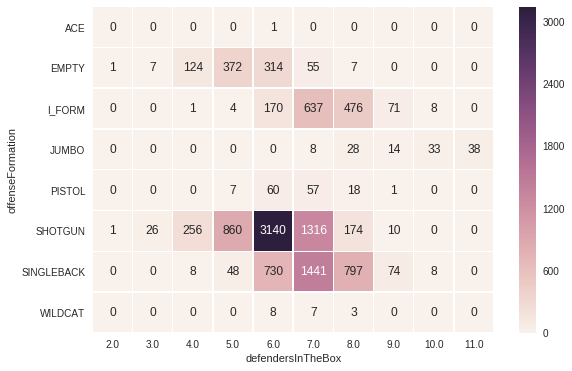

In [0]:
f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(crosstab, annot=True, fmt="d", linewidths=.5, ax=ax);